# Worksheet 4 -- Linear Regression

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data.csv', on_bad_lines='skip', header=12)
sample_A = df.dropna()
sample_A['pl_masse_err'] = (np.abs(sample_A['pl_masseerr1']) + np.abs(sample_A['pl_masseerr2'])) / 2.0

print("The new dataset has {} planets. Down from the original {}.".format(len(sample_A), len(df)))

The new dataset has 2921 planets. Down from the original 39816.


In [3]:
sample_B = sample_A[sample_A['pl_rade'] <= 5]
print(sample_B)

          pl_name  pl_rade  pl_masse  pl_masseerr1  pl_masseerr2  st_mass  \
117      55 Cnc e    1.947      8.59          0.43         -0.43    1.015   
122      55 Cnc e    1.875      7.99          0.32         -0.33    0.905   
123      55 Cnc e    2.173      8.37          0.38         -0.38    0.900   
129      55 Cnc e    2.080      7.81          0.58         -0.53    0.905   
131      55 Cnc e    1.897      7.74          0.37         -0.30    0.873   
...           ...      ...       ...           ...           ...      ...   
39582  Wolf 503 b    2.043      6.26          0.69         -0.70    0.688   
39583  Wolf 503 b    2.043      6.27          0.85         -0.84    0.688   
39755    pi Men c    2.060      4.52          0.81         -0.81    1.020   
39759    pi Men c    2.110      4.30          0.70         -0.70    1.070   
39762    pi Men c    2.042      4.82          0.84         -0.86    1.094   

       pl_masse_err  
117           0.430  
122           0.325  
123      

Text(0, 0.5, 'Mass (Earth masses)')

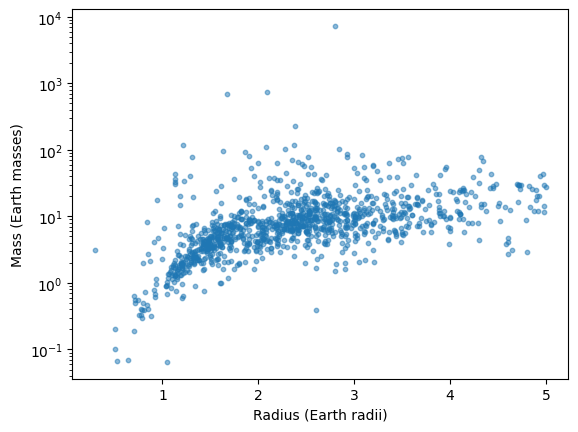

In [4]:
plt.scatter(sample_B['pl_rade'], sample_B['pl_masse'], alpha=0.5, s=10)
plt.yscale('log')
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')

In [5]:
# When all the uncertainties are the same, the least squares fit is equvalent to maximum likelihood estimate. We can use np.linalg.lstsq to find the best fit line.

# We are working in log space.
log_R = np.log10(sample_B['pl_rade'].values)
log_M = np.log10(sample_B['pl_masse'].values)

# lstsq expects a (M, N) array for the coefficient matrix.
X = np.column_stack([log_R, np.ones(len(log_R))])

x, residuals, rank, s = np.linalg.lstsq(X, log_M, rcond=None)
print(x, s)

[1.55004808 0.32657474] [35.82727282  5.75590512]


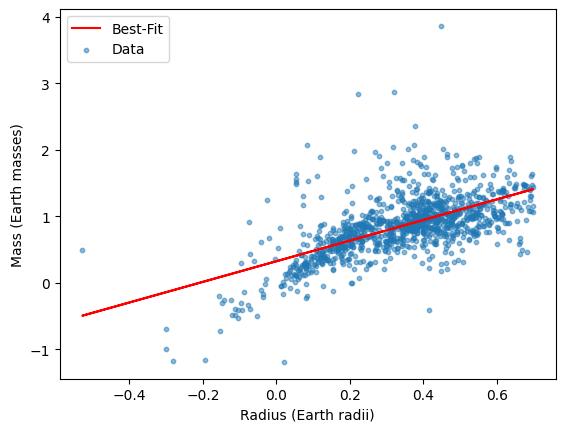

In [6]:
# Plot of best fit.
plt.plot(log_R, x[0] * log_R + x[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [7]:
earth_radius_km = 6378.13
eath_mass_kg = 5.972e24

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = x[0] * log_Radius + x[1]     # Apply the fitted model
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']:.3f}")

Mercury : predicted = 0.478, actual = 0.330
Venus   : predicted = 1.955, actual = 4.867
Earth   : predicted = 2.117, actual = 5.972
Mars    : predicted = 0.796, actual = 0.642
Jupiter : predicted = 86.775, actual = 1898.125
Saturn  : predicted = 65.365, actual = 568.317
Uranus  : predicted = 18.022, actual = 86.810
Neptune : predicted = 17.214, actual = 102.409


In [8]:
# Propagate uncertainties into log space
# σ(log10 M) ≈ σ_M / (M * ln(10))
sigma_logM = sample_B['pl_masse_err'].values / (sample_B['pl_masse'].values * np.log(10))

# In WLS, we weight each data point by 1/σ², so we divide by the uncertainty
# This is equivalent to MLE with Gaussian errors
weights = 1.0 / sigma_logM

# Build the weighted design matrix and target
X = np.column_stack([log_R, np.ones(len(log_R))])
X_w = X * weights[:, np.newaxis]    # Multiply each row by its weight
y_w = log_M * weights               # Multiply target by same weights

# Solve the weighted normal equations
x_2, residuals_2, rank_2, s_2 = np.linalg.lstsq(X_w, y_w, rcond=None)

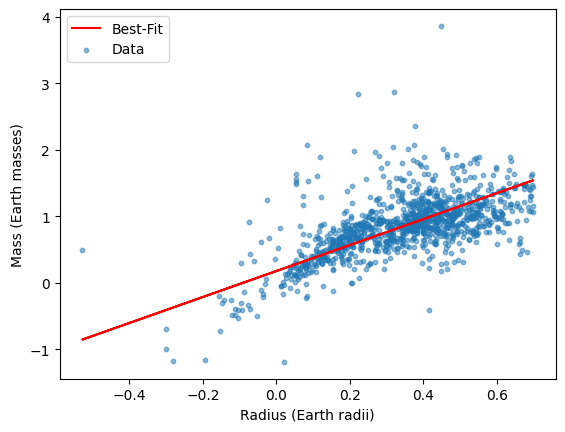

In [9]:
plt.plot(log_R, x_2[0] * log_R + x_2[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [10]:
earth_radius_km = 6378.13
earth_mass_kg = 5.972

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = x_2[0] * log_Radius + x_2[1]     # Apply the fitted model
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']/earth_mass_kg:.3f}")

Mercury : predicted = 0.232, actual = 0.055
Venus   : predicted = 1.365, actual = 0.815
Earth   : predicted = 1.509, actual = 1.000
Mars    : predicted = 0.440, actual = 0.107
Jupiter : predicted = 161.754, actual = 317.837
Saturn  : predicted = 113.223, actual = 95.164
Uranus  : predicted = 22.360, actual = 14.536
Neptune : predicted = 21.104, actual = 17.148


In [11]:
from numpy.polynomial import polynomial as P

In [12]:
log_R_A = np.log10(sample_A['pl_rade'].values)
log_M_A = np.log10(sample_A['pl_masse'].values)
sigma_logM_A = sample_A['pl_masse_err'].values / (
    sample_A['pl_masse'].values * np.log(10))

# We need to create a smooth grid for plotting.
log_R_plot = np.linspace(log_R_A.min(), log_R_A.max(), len(log_R_A))

weights_A = 1.0 / sigma_logM_A

# Build a polynomial design matrix of degree d
# Each column is (log R)^k for k = 0, 1, ..., d
def make_poly_design_matrix(log_R, degree):
    return np.column_stack([log_R**k for k in range(degree + 1)])

# Example: fit degree 3
d = 6
X_poly = make_poly_design_matrix(log_R_A, d)
X_poly_w = X_poly * weights_A[:, np.newaxis]
y_w_A = log_M_A * weights_A

x_3, residuals_3, rank_3, s_3 = np.linalg.lstsq(X_poly_w, y_w_A, rcond=None)
print(f"Polynomial coefficients (degree {d}): {x_3}")

Polynomial coefficients (degree 6): [  0.26364769   5.02196834 -24.07968387  50.40677286 -35.43855834
   4.8978503    1.81148217]


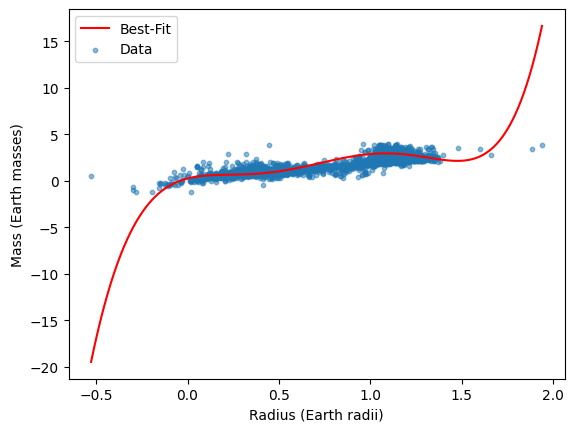

In [13]:
plt.plot(log_R_plot, np.polyval(x_3[::-1], log_R_plot), label='Best-Fit', c='red')
plt.scatter(log_R_A, log_M_A, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [14]:
earth_radius_km = 6378.13
earth_mass_kg = 5.972

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = np.polyval(x_3[::-1], log_Radius)
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']/earth_mass_kg:.3f}")

Mercury : predicted = 0.000, actual = 0.055
Venus   : predicted = 1.368, actual = 0.815
Earth   : predicted = 1.825, actual = 1.000
Mars    : predicted = 0.000, actual = 0.107
Jupiter : predicted = 862.032, actual = 317.837
Saturn  : predicted = 634.771, actual = 95.164
Uranus  : predicted = 23.255, actual = 14.536
Neptune : predicted = 20.715, actual = 17.148


In [15]:
log_R_A = np.log10(sample_A['pl_rade'].values)
log_Mstar_A = np.log10(sample_A['st_mass'].values)
log_M_A = np.log10(sample_A['pl_masse'].values)
weights_A = 1.0 / sigma_logM_A

In [16]:
X_2d = np.column_stack([log_R_A, log_Mstar_A, np.ones(len(log_R_A))])
X_2d_w = X_2d * weights_A[:, np.newaxis]
y_w_A = log_M_A * weights_A

In [17]:
coeffs_2d, _, _, _ = np.linalg.lstsq(X_2d_w, y_w_A, rcond=None)
a, b, c = coeffs_2d
print(f"2D fit: log M = {a:.3f}·log R + {b:.3f}·log M★ + {c:.3f}")

2D fit: log M = 1.969·log R + 0.750·log M★ + 0.719


In [19]:
earth_radius_km = 6378.13
earth_mass_kg = 5.972

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

# Solar mass of the sun is 1.
log_Mstar_sun = np.log10(1.0)

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = a * log_Radius + b * log_Mstar_sun + c
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']/earth_mass_kg:.3f}")

Mercury : predicted = 0.789, actual = 0.055
Venus   : predicted = 4.723, actual = 0.815
Earth   : predicted = 5.226, actual = 1.000
Mars    : predicted = 1.508, actual = 0.107
Jupiter : predicted = 584.736, actual = 317.837
Saturn  : predicted = 407.966, actual = 95.164
Uranus  : predicted = 79.383, actual = 14.536
Neptune : predicted = 74.886, actual = 17.148
